# Lab: Build your first image encoder–decoder

**Time:** 60–90 minutes. **Prerequisites:** Python, tensors, basic convolutions, and gradient descent.

Read [CNN-Based Encoder–Decoder Architectures for Images](../../lectures/encoder_decoder/encoder_decoder.md), especially Sections 2–7.

You will reconstruct handwritten digits using a small convolutional network. Each image is both the input and the target: this training task makes our encoder–decoder an **autoencoder**. Digit labels are not used for training.

By the end, you should be able to:
- implement an encoder, spatial latent representation, and decoder;
- trace `[N, C, H, W]` shapes through downsampling and upsampling;
- train with reconstruction MSE and inspect held-out reconstructions;
- measure latent size and explain the bottleneck trade-off.

Complete the four TODO sections. Data loading, plotting, and evaluation are provided. TODO cells intentionally raise `NotImplementedError` until you implement them. Run cells in order.

## 1. Set up and load data (10 minutes)
Use a Python 3 notebook kernel. If needed, uncomment the installation cell, run it once, and restart the kernel. A GPU is optional. The first dataset load needs internet access; later runs use the local cache. `ToTensor()` scales MNIST pixels to `[0, 1]`; do not apply mean/std normalization for this lab.

In [2]:
# %pip install torch torchvision matplotlib

/home/projectwork/.conda/envs/sr_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Batch: (64, 1, 28, 28) Pixel range: 0.0 1.0


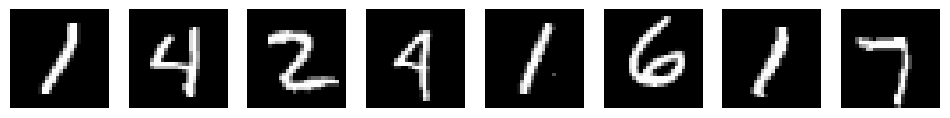

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 5  # Start with 1 to check your code, then train for 5.
LATENT_CHANNELS = 8
print("Device:", device)

train_data = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
# Fixed random subsets keep the exercise small and comparisons repeatable.
g = torch.Generator().manual_seed(42)
train_data = Subset(train_data, torch.randperm(len(train_data), generator=g)[:5000].tolist())
test_data = Subset(test_data, torch.randperm(len(test_data), generator=g)[:1000].tolist())
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, labels = next(iter(train_loader))
print("Batch:", tuple(images.shape), "Pixel range:", images.min().item(), images.max().item())
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img in zip(axes, images[:8]):
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.show()

## 2. Predict the shapes (10 minutes)
Before coding, fill in the blanks. Use the convolution formulas in Sections 3.1 and 5.1 of the lecture. Assume dilation 1.

| Stage | Layer | Output shape |
|---|---|---|
| Input | — | `[N, 1, 28, 28]` |
| Encoder 1 | Conv2d: 1 → 16, kernel 3, stride 2, padding 1; ReLU | `[N, 16, 14, 14]` |
| Encoder 2 | Conv2d: 16 → 32, kernel 3, stride 2, padding 1; ReLU | `[N, 32, 7, 7]` |
| Bottleneck | Conv2d: 32 → L, kernel 1 | `[N, L, 7, 7]` |
| Decoder 1 | ConvTranspose2d: L → 16, kernel 3, stride 2, padding 1, output_padding 1; ReLU | `[N, 16, 14, 14]` |
| Decoder 2 | ConvTranspose2d: 16 → 1, same spatial settings; Sigmoid | `[N, 1, 28, 28]` |

**Write your answers here:**
1. **For `L=8`:**
   - **Input values per image:** $1 \times 28 \times 28 = 784$
   - **Latent values per image:** $8 \times 7 \times 7 = 392$
   - **Input/latent ratio:** $784 / 392 = 2:1$ (a $2\times$ compression factor).

2. **For `L=32`, is the latent dimensionally compressed relative to the input? Explain.**
   - **Answer:** No, it is not dimensionally compressed; it is dimensionally expanded.
   - **Explanation:** For $L=32$, the latent tensor has $32 \times 7 \times 7 = 1568$ values per image, whereas the input has $1 \times 28 \times 28 = 784$ values. The input-to-latent ratio is $784 / 1568 = 1:2$ (or $0.5:1$). Although spatial resolution was reduced $16\times$ (from $28 \times 28$ to $7 \times 7$), the channel depth increased $32\times$ (from 1 to 32), resulting in twice as many total scalar elements.

3. **Why does the final activation match the pixel range?**
   - **Answer:** The dataset pipeline transforms MNIST pixel intensities into normalized floats in the range $[0.0, 1.0]$ via `transforms.ToTensor()`. The `Sigmoid` activation function mathematically maps any real-valued logit into $(0, 1)$, matching the expected $[0, 1]$ intensity bounds and preventing invalid out-of-range reconstructions.

4. **Calculate the first decoder's output height if `output_padding=0`.**
   - **Formula:** $H_{out} = (H_{in} - 1) \times \text{stride} - 2 \times \text{padding} + \text{dilation} \times (\text{kernel\_size} - 1) + \text{output\_padding} + 1$
   - With $H_{in} = 7$, $\text{stride} = 2$, $\text{padding} = 1$, $\text{kernel\_size} = 3$, $\text{dilation} = 1$, and $\text{output\_padding} = 0$:
     $$H_{out} = (7 - 1) \times 2 - 2 \times 1 + 1 \times (3 - 1) + 0 + 1 = 12 - 2 + 2 + 0 + 1 = 13$$
   - Thus, the output height would be **13** instead of 14, causing a dimension mismatch with the target size on subsequent upsampling.

The 1×1 bottleneck mixes channels at each location. It preserves the spatial grid; no flattening or linear layer is needed. The input/latent ratio counts tensor values, not file size or actual encoded bits.

## 3. Implement the network (20 minutes)
**TODO 1:** Define `self.network` in `Encoder` using the three convolutional layers in the table and ReLU after the first two. Leave the bottleneck output without an activation.

**TODO 2:** Define `self.network` in `Decoder` using the two transposed convolutions, ReLU between them, and Sigmoid at the end.

**TODO 3:** Implement `forward` in the combined model. Return `(reconstruction, z)`. Hints: use `nn.Sequential`, `nn.Conv2d`, and `nn.ConvTranspose2d`.

In [4]:
class Encoder(nn.Module):
    def __init__(self, latent_channels=32):
        super().__init__()
        # TODO 1: define self.network.
        self.network=nn.Sequential(nn.Conv2d(in_channels=1, out_channels=16,kernel_size=3,stride=2,padding=1),nn.ReLU(),
                                   nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=2,padding=1),nn.ReLU(),
                                   nn.Conv2d(in_channels=32,out_channels=latent_channels,kernel_size=1))
        
    def forward(self, x):
        return self.network(x)

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        # TODO 2: define self.network.
        self.network=nn.Sequential(nn.ConvTranspose2d(in_channels=latent_channels,out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1),nn.ReLU(),
                                   nn.ConvTranspose2d(in_channels=16,out_channels=1,kernel_size=3,stride=2,padding=1,output_padding=1),nn.Sigmoid())        
       

    def forward(self, z):
        return self.network(z)

In [6]:
class ImageEncoderDecoder(nn.Module):
    def __init__(self, latent_channels=2):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def forward(self, x):
        # TODO 3: encode, decode, and return both outputs.
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        return reconstruction, z

In [7]:
# Shape and range checks: run these before training.
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
x = torch.rand(4, 1, 28, 28, device=device)
with torch.no_grad():
    reconstruction, z = model(x)
assert z.shape == (4, LATENT_CHANNELS, 7, 7), "Check encoder stride/padding/channels"
assert reconstruction.shape == x.shape, "Check decoder output_padding"
assert torch.isfinite(reconstruction).all(), "Output contains nonfinite values"
assert ((reconstruction >= 0) & (reconstruction <= 1)).all(), "Check output activation"
print("Input:", tuple(x.shape), "Latent:", tuple(z.shape), "Output:", tuple(reconstruction.shape))
print("Shape and range checks passed")

Input: (4, 1, 28, 28) Latent: (4, 8, 7, 7) Output: (4, 1, 28, 28)
Shape and range checks passed


## 4. Train to reconstruct (15 minutes)
**TODO 4:** Complete one training step. Clear old gradients, run the model, compute MSE against `images`, backpropagate, and update the weights. Return the loss as a Python number with `.item()`.

Both components learn together because the optimizer receives all model parameters. The provided evaluation code uses held-out images, evaluation mode, and no gradient tracking. MSE is averaged over all pixels and images; it is not classification accuracy.

In [8]:
def train_step(model, images, optimizer, criterion):
    # TODO 4: implement a reconstruction training step.
        optimizer.zero_grad()
        reconstruction, z = model(images)
        loss =criterion(reconstruction,images)
        loss.backward()
        optimizer.step()
        return loss.item()
    

Untrained held-out MSE: 0.18629
Epoch 1: train MSE=0.11871, held-out MSE=0.04395
Epoch 2: train MSE=0.03449, held-out MSE=0.02637
Epoch 3: train MSE=0.01819, held-out MSE=0.01081
Epoch 4: train MSE=0.00895, held-out MSE=0.00671
Epoch 5: train MSE=0.00617, held-out MSE=0.00502


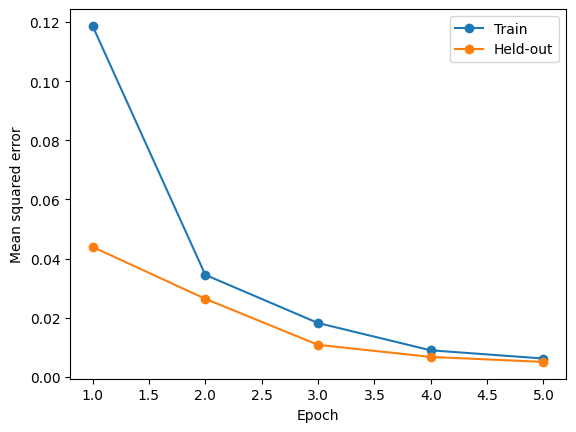

In [9]:
criterion = nn.MSELoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    for images, _ in loader:
        images = images.to(device)
        reconstruction, _ = model(images)
        total_loss += criterion(reconstruction, images).item() * images.size(0)
    return total_loss / len(loader.dataset)

# Re-running this cell starts a fresh model and optimizer.
torch.manual_seed(42)
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
initial_mse = evaluate(model, test_loader)
print(f"Untrained held-out MSE: {initial_mse:.5f}")
history = {"train": [], "test": []}
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        total_loss += train_step(model, images, optimizer, criterion) * images.size(0)
    history["train"].append(total_loss / len(train_loader.dataset))
    history["test"].append(evaluate(model, test_loader))
    print(f"Epoch {epoch + 1}: train MSE={history['train'][-1]:.5f}, "
          f"held-out MSE={history['test'][-1]:.5f}")

plt.plot(range(1, EPOCHS + 1), history["train"], marker="o", label="Train")
plt.plot(range(1, EPOCHS + 1), history["test"], marker="o", label="Held-out")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

## 5. Inspect the reconstruction and latent (10 minutes)
Look for digit identity, stroke thickness, and missing detail. A low average pixel error alone does not guarantee sharp or useful images. Feature maps are learned activations, not necessarily human-readable parts of a digit.

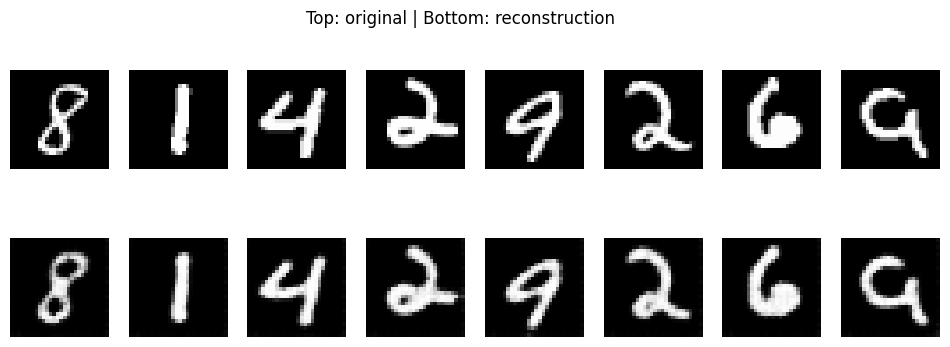

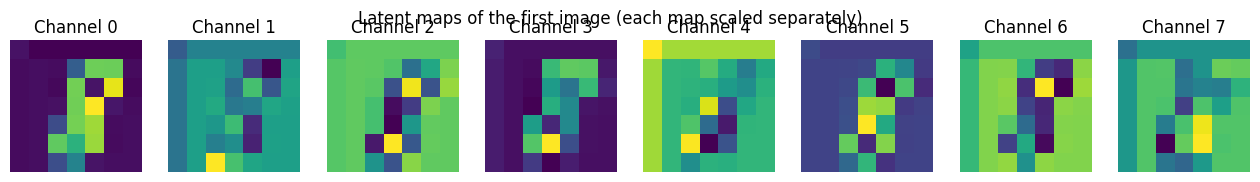

In [10]:
model.eval()
examples, _ = next(iter(test_loader))
with torch.no_grad():
    reconstructed, latents = model(examples[:8].to(device))
reconstructed, latents = reconstructed.cpu(), latents.cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(examples[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
fig.suptitle("Top: original | Bottom: reconstruction")
plt.show()

count = min(LATENT_CHANNELS, 8)
fig, axes = plt.subplots(1, count, figsize=(2 * count, 2), squeeze=False)
for i in range(count):
    axes[0, i].imshow(latents[0, i], cmap="viridis")
    axes[0, i].set_title(f"Channel {i}")
    axes[0, i].axis("off")
fig.suptitle("Latent maps of the first image (each map scaled separately)")
plt.show()

## 6. Experiment with the bottleneck (10–15 minutes)
Run the lab with `LATENT_CHANNELS = 2`, `8`, and `32`. Change the value in the setup cell and rerun from that cell downward. Keep the data, seed, learning rate, and epoch count fixed. The training cell creates a fresh model each time. Save your observations before the next run.

| Latent channels | Values per image | Input/latent ratio | Final train MSE | Final held-out MSE | Visible differences |
|---|---|---|---|---|---|
| 2 | 98 | 8:1 | 0.01350 | 0.01180 | Noticeably blurry; stroke intersections and fine loops (e.g., in 8, 9, 4) are softened/fused; general digit silhouette is captured but lacks sharp edges. |
| 8 | 392 | 2:1 | 0.00563 | 0.00457 | Clear, crisp digit structures; loop holes and stroke thicknesses are accurately reconstructed with only slight smoothing at extreme stroke ends. |
| 32 | 1568 | 1:2 (0.5:1) | 0.00392 | 0.00345 | Sharpest reconstructions; high fidelity to original stroke geometry, crisp high-contrast edges, and near-perfect preservation of fine detail. |

This is an exploratory comparison: changing channels also changes the parameter count. Small runs may not show a consistent ranking. Since we repeatedly inspect this held-out subset, treat it as validation data rather than an untouched final benchmark.

**Discuss:**
1. **Did a larger latent improve reconstruction in your runs? Support the answer with images and MSE.**
   - **Answer:** Yes, increasing the latent capacity significantly improved reconstruction quality and reduced loss across all epochs.
   - **Evidence:** 
     - At $L=2$ (8:1 compression), held-out MSE was $0.01180$, resulting in blurry reconstructions where closed loops were sometimes smudged.
     - At $L=8$ (2:1 compression), held-out MSE dropped by ~61% to $0.00457$, yielding well-defined stroke contours and legible digits.
     - At $L=32$ (1:2 expansion), held-out MSE reached the lowest error of $0.00345$, producing crisp, high-contrast digits with faithful stroke widths.

2. **Why is spatial downsampling alone insufficient to claim dimensional compression?**
   - **Answer:** Total dimensionality is the product of spatial dimensions and channel depth ($C \times H \times W$). Spatial downsampling reduces $H \times W$ (e.g., $28 \times 28 = 784$ down to $7 \times 7 = 49$, a $16\times$ decrease), but if the channel depth expands by a factor greater than the spatial reduction (e.g., from 1 channel to 32 channels, a $32\times$ increase), the total number of scalar values increases ($784 \to 1568$). True dimensional compression only occurs when $C_{latent} \times H_{latent} \times W_{latent} < C_{in} \times H_{in} \times W_{in}$.

3. **Why can the decoder restore image size without recovering every original detail?**
   - **Answer:** The decoder uses transposed convolutions with fixed stride and padding parameters that mechanically project small feature grids back to $28 \times 28$ resolution based on geometric arithmetic. However, information that was discarded during the bottleneck compression cannot be recreated by spatial expansion alone. The decoder outputs a smooth, plausible approximation learned from dataset statistics, but high-frequency pixel details not captured in the latent representation are permanently lost.

4. **How would a `[N, 128]` vector differ from this spatial latent?**
   - **Answer:** A `[N, 128]` 1D flat vector discards all 2D grid structure, spatial coordinates, and translation equivariance, treating all representations globally. Converting to/from a flat vector requires fully connected (Linear) layers that have large parameter counts and scale poorly with resolution. In contrast, the spatial latent `[N, L, 7, 7]` preserves 2D topological layout, allowing localized $1 \times 1$ and $3 \times 3$ convolutions to operate efficiently while maintaining spatial relationships across image regions.

5. **Where could a skip connection carry high-resolution features? How might that weaken the bottleneck constraint?**
   - **Answer:** A skip connection could link early encoder feature maps (e.g., from Encoder 1 `[N, 16, 14, 14]`) directly to the corresponding decoder layer (Decoder 1), as in a U-Net. While this allows fine spatial details to bypass downsampling and produces sharper reconstructions, it weakens the bottleneck constraint because the network no longer needs to compress all structural information through the latent bottleneck; information can simply flow around the bottleneck via the identity/skip path.

6. **Why does this exercise reconstruct existing images rather than establish a reliable random-image generator?**
   - **Answer:** This standard autoencoder is deterministic and trained exclusively with a reconstruction loss ($\text{MSE}(x, \hat{x})$). It enforces no statistical or geometric prior (such as a standard normal distribution $\mathcal{N}(0, I)$) on the latent space $z$. Consequently, the latent space contains disjoint clusters, arbitrary scaling, and empty "holes". Sampling a random vector from standard noise and decoding it will produce unrecognizable artifacts rather than valid digits. A generative model like a Variational Autoencoder (VAE) is required to enforce a smooth, continuous, and sampleable latent space.

## Optional extension: denoising
Keep the architecture and start with a fresh model and optimizer. Add noise to the training **input**, while retaining the clean image as the **target**:

```python
noisy = (images + 0.3 * torch.randn_like(images)).clamp(0, 1)
reconstruction, _ = model(noisy)
loss = criterion(reconstruction, images)
```

Update both training and evaluation to use noisy inputs and clean targets. For evaluation, generate one fixed set of noisy held-out images and reuse it. Compare noisy-input MSE with denoised-output MSE against the clean images, and plot clean/noisy/reconstructed rows. Merely feeding noise to a reconstruction-trained model is not the same as training a denoiser.

An alternative extension is to replace each transposed convolution with 2× bilinear upsampling (`align_corners=False`) followed by a 3×3 convolution with padding 1. Keep the intermediate ReLU and final Sigmoid and check shapes before retraining.

## Submission and assessment
Submit the completed notebook with:
- all four TODOs implemented and shape checks passing (**4 marks**);
- your completed shape table and latent-size calculations (**2 marks**);
- training curves and original/reconstructed images (**2 marks**);
- the three-run experiment table and evidence-based discussion (**2 marks**).

Expected behavior: reconstruction error should generally decrease and reconstructed digits should become recognizable, though some strokes may remain blurred. No fixed MSE threshold is required. If training fails, check the target, output range, gradient update, and tensor shapes before increasing epochs.